# Customer Churn Prediction — Feature Engineering

## Business Problem

Energy providers operate in a competitive market where customers can easily switch suppliers. Understanding the drivers of churn is critical for improving customer retention.

This notebook focuses on **feature engineering** to create meaningful predictors that can improve the performance of churn prediction models.

The engineered features capture:

• Customer contract lifecycle  
• Price sensitivity and price shocks  
• Consumption behaviour  
• Customer profitability

## Project Objective

The goal of this notebook is to transform raw data into **high-quality predictive features** that help identify customers likely to churn.

The analysis will focus on:

• Detecting price sensitivity signals  
• Identifying behavioural patterns before churn  
• Capturing customer lifecycle information  
• Estimating customer value

These engineered features will later be used to build a predictive churn model.

## Import Libraries

In [ ]:
# Import core Python libraries

import pandas as pd
import numpy as np

Import Visualization Libraries

In [ ]:
# Import visualization libraries for charts

import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional plotting style
sns.set(style="whitegrid")

## Load Dataset

In [3]:
# Load cleaned dataset generated after EDA

df = pd.read_csv("clean_data_after_eda.csv")

# Preview dataset
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,0.000011,2.896760e-06,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0


## Dataset Overview

In [4]:
# Inspect dataset structure and metadata

# Dataset dimensions
df.shape

# Column names
df.columns

# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

## Visualization: Churn Distribution

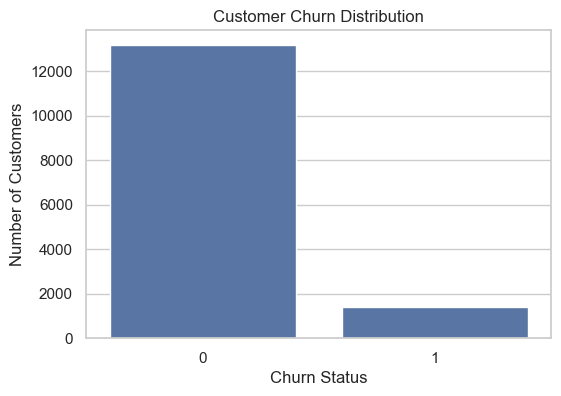

In [5]:
# Visualize churn vs non-churn distribution

plt.figure(figsize=(6,4))

sns.countplot(x="churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

## Insight: Churn Distribution

This visualization shows the number of customers who churned compared to those who stayed.

Understanding this distribution helps identify whether the dataset is imbalanced.  
If churned customers represent a small percentage, evaluation metrics such as **precision, recall, and ROC-AUC** will be more appropriate than accuracy.

## Convert Date Columns

In [6]:
# Convert string date columns to datetime format

df["date_activ"] = pd.to_datetime(df["date_activ"])
df["date_end"] = pd.to_datetime(df["date_end"])
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"])
df["date_renewal"] = pd.to_datetime(df["date_renewal"])

## Date Feature Engineering

In [7]:
# Extract useful information from date columns

df["activation_year"] = df["date_activ"].dt.year
df["activation_month"] = df["date_activ"].dt.month

df["end_year"] = df["date_end"].dt.year
df["end_month"] = df["date_end"].dt.month

df["renewal_month"] = df["date_renewal"].dt.month

## Contract Lifecycle Features

In [8]:
# Create features related to contract lifecycle

# Total contract duration
df["contract_duration_days"] = (df["date_end"] - df["date_activ"]).dt.days

# Customer tenure
df["customer_tenure_days"] = (df["date_renewal"] - df["date_activ"]).dt.days

# Remaining contract duration
df["remaining_contract_days"] = (df["date_end"] - df["date_renewal"]).dt.days

## Price Behaviour Features

In [9]:
# Capture pricing dynamics affecting churn

# Peak vs off-peak price difference
df["price_diff_peak_offpeak"] = (
    df["forecast_price_energy_peak"] -
    df["forecast_price_energy_off_peak"]
)

# Average yearly price variation
df["avg_price_variation"] = (
    df["var_year_price_off_peak"] +
    df["var_year_price_peak"] +
    df["var_year_price_mid_peak"]
) / 3

# Average 6 month variation
df["avg_6m_price_variation"] = (
    df["var_6m_price_off_peak"] +
    df["var_6m_price_peak"] +
    df["var_6m_price_mid_peak"]
) / 3

# Price sensitivity index
df["price_sensitivity_index"] = (
    df["var_year_price_off_peak"] +
    df["var_year_price_peak"] +
    df["var_year_price_mid_peak"]
)

## Price Shock Indicator

In [10]:
# Detect sudden price increases

price_shock_threshold = 0.1

df["price_shock_flag"] = (
    df["var_year_price_off_peak"] > price_shock_threshold
).astype(int)

## Visualization: Price Sensitivity vs Churn

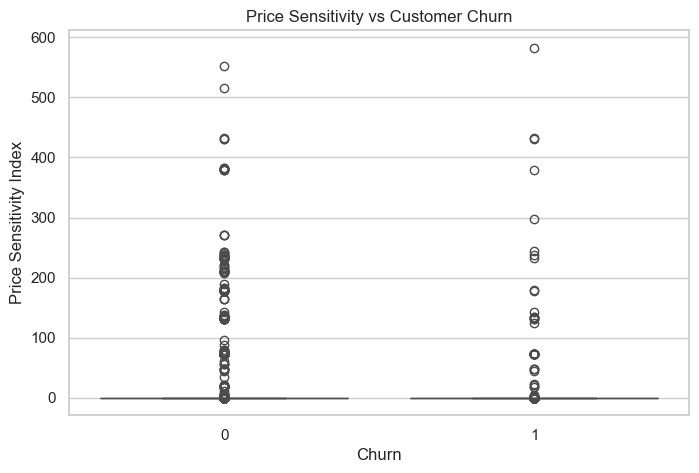

In [11]:
# Visualize relationship between price sensitivity and churn

plt.figure(figsize=(8,5))

sns.boxplot(x="churn", y="price_sensitivity_index", data=df)

plt.title("Price Sensitivity vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Price Sensitivity Index")

plt.show()

## Insight: Price Sensitivity

Customers with higher price sensitivity may be more likely to churn when tariffs increase.

If churned customers show higher price sensitivity values, the company may consider targeted pricing strategies or retention offers.

## Consumption Features

In [12]:
# Capture customer consumption behaviour

# Consumption stability
df["consumption_stability"] = df["cons_last_month"] / (df["cons_12m"] + 1)

## Visualization - Consumption vs Churn

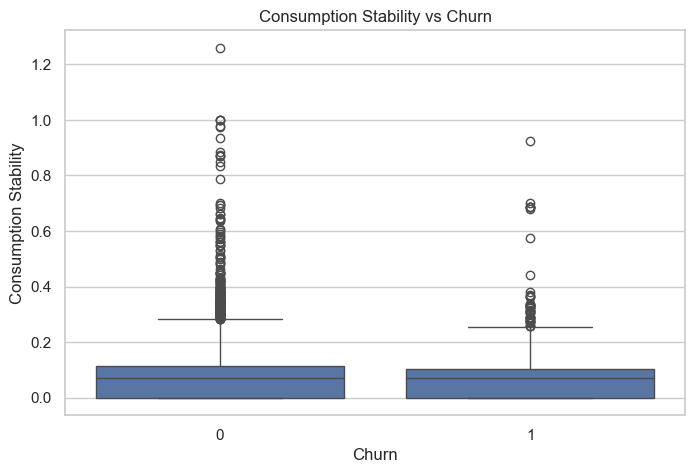

In [13]:
# Visualize relationship between consumption stability and churn

plt.figure(figsize=(8,5))

sns.boxplot(x="churn", y="consumption_stability", data=df)

plt.title("Consumption Stability vs Churn")
plt.xlabel("Churn")
plt.ylabel("Consumption Stability")

plt.show()

## Insight: Consumption Behaviour

A drop in consumption or unstable usage patterns may indicate customer disengagement.

Monitoring consumption trends can provide early warning signals of potential churn.

## Consulting Feature (Consumption Drop)

In [14]:
# Detect abnormal drop in consumption

df["expected_monthly_consumption"] = df["cons_12m"] / 12

df["consumption_drop_ratio"] = (
    df["cons_last_month"] /
    (df["expected_monthly_consumption"] + 1)
)

df["consumption_drop_flag"] = (
    df["consumption_drop_ratio"] < 0.5
).astype(int)

## Price per Consumption

In [15]:
# Measure price burden relative to consumption

df["price_per_consumption"] = (
    df["forecast_price_energy_off_peak"] /
    (df["cons_12m"] + 1)
)

## Profitability Feature

In [18]:
# Estimate profitability of each customer

df["total_margin"] = (
    df["margin_gross_pow_ele"] +
    df["margin_net_pow_ele"]
)

## CLV Proxy

In [19]:
# Estimate customer lifetime value proxy

df["clv_proxy"] = (
    df["cons_12m"] *
    df["margin_net_pow_ele"]
)

## Encode Categorical Variable

In [20]:
# Convert categorical variable into numeric format

df["has_gas"] = df["has_gas"].map({"t":1, "f":0})


## Remove Unnecessary Columns

In [21]:
# Remove columns not required for modeling

df = df.drop(columns=["id"])

df = df.drop(columns=[
    "date_activ",
    "date_end",
    "date_modif_prod",
    "date_renewal"
])

## Final Dataset Inspection

In [32]:
# Inspect final dataset after feature engineering

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 59 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   channel_sales                   14606 non-null  object 
 1   cons_12m                        14606 non-null  int64  
 2   cons_gas_12m                    14606 non-null  int64  
 3   cons_last_month                 14606 non-null  int64  
 4   forecast_cons_12m               14606 non-null  float64
 5   forecast_cons_year              14606 non-null  int64  
 6   forecast_discount_energy        14606 non-null  float64
 7   forecast_meter_rent_12m         14606 non-null  float64
 8   forecast_price_energy_off_peak  14606 non-null  float64
 9   forecast_price_energy_peak      14606 non-null  float64
 10  forecast_price_pow_off_peak     14606 non-null  float64
 11  has_gas                         14606 non-null  int64  
 12  imp_cons                        

,channel_sales,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,avg_6m_price_variation,price_sensitivity_index,price_shock_flag,consumption_stability,expected_monthly_consumption,consumption_drop_ratio,consumption_drop_flag,price_per_consumption,total_margin,clv_proxy
0,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,0.00,0,0.0,1.78,0.114481,0.098142,...,48.617895,72.676550,1,0.000000,0.000000,0.000000,1,0.114481,50.88,0.00
1,MISSING,4660,0,0,189.95,0,0.0,16.27,0.145711,0.000000,...,0.003568,0.007079,0,0.000000,388.333333,0.000000,1,0.000031,32.76,76330.80
2,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,47.96,0,0.0,38.72,0.165794,0.087899,...,0.000001,0.007668,0,0.000000,45.333333,0.000000,1,0.000304,57.20,15558.40
3,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,240.04,0,0.0,19.83,0.146694,0.000000,...,0.000001,0.006470,0,0.000000,132.000000,0.000000,1,0.000093,60.44,47868.48
4,MISSING,4425,0,526,445.75,526,0.0,131.73,0.116900,0.100015,...,0.000005,0.008273,0,0.118843,368.750000,1.422583,0,0.000026,89.82,198726.75


## Correlation Heatmap

The correlation heatmap helps identify which features are most strongly associated with churn.

Features showing stronger correlation with churn may have higher predictive value for machine learning models.

Examples of potential churn drivers may include:

• Price sensitivity indicators  
• Consumption stability metrics  
• Contract lifecycle variables  

This step helps validate the usefulness of engineered features before training predictive models.

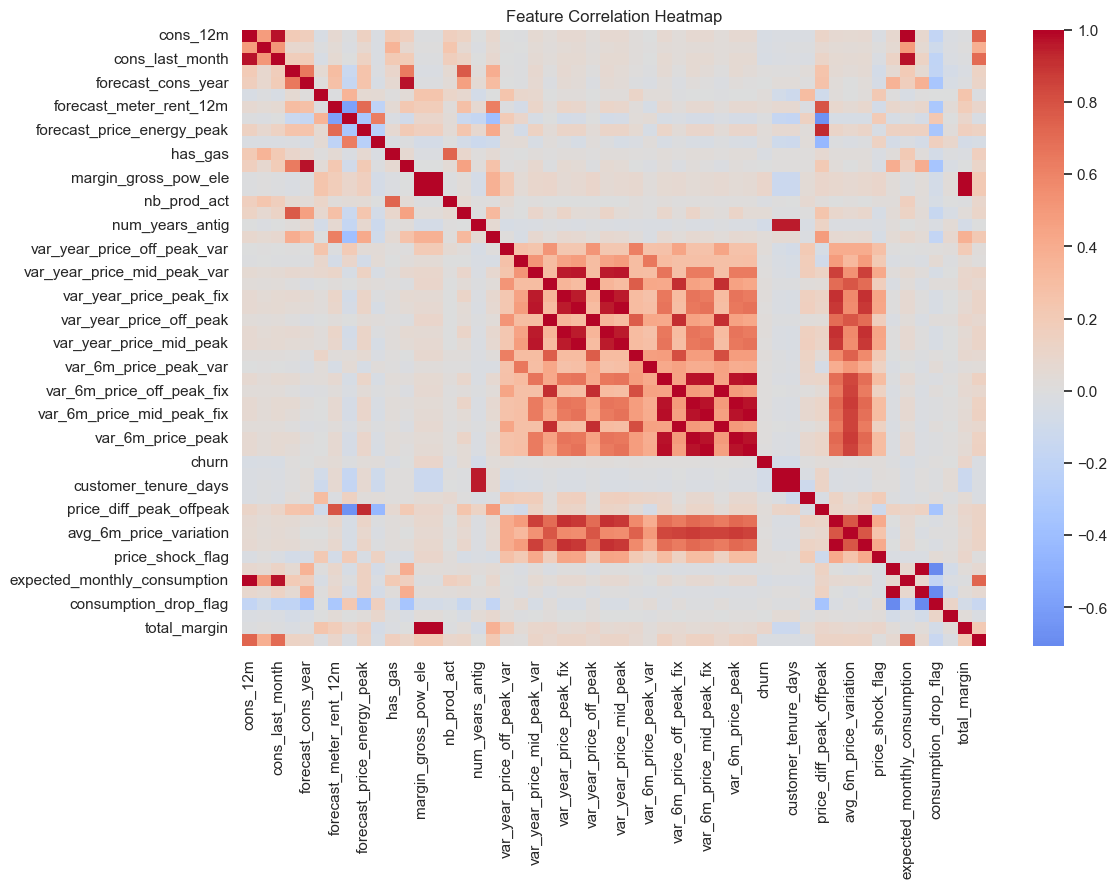

In [33]:
# Analyze feature correlations with churn

# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64","float64"])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Feature Correlation Heatmap")
plt.show()

## Quick Baseline Model

To validate whether the engineered features contain predictive signal, a baseline Random Forest model is trained. 

Categorical variables are encoded using one-hot encoding to ensure compatibility with machine learning algorithms.

In [34]:
# Convert categorical variables into numeric variables

df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features and target variable
X = df_encoded.drop("churn", axis=1)
y = df_encoded["churn"]

In [35]:
# Train a baseline Random Forest model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

# Evaluate model
print("Baseline Model Accuracy:", model.score(X_test, y_test))

Baseline Model Accuracy: 0.9021218343600274


In [36]:
# Verify dataset is fully numeric

df_encoded.select_dtypes(include="object").columns

Index([], dtype='object')

## Save Dataset

In [37]:
# Save feature engineered dataset

df.to_csv("feature_engineered_data.csv", index=False)

## Feature Engineering Summary

The following categories of features were created:

### Contract Lifecycle
• Customer tenure  
• Contract duration  
• Remaining contract days  

### Price Behaviour
• Price sensitivity index  
• Price shock indicator  

### Consumption Behaviour
• Consumption stability  
• Consumption drop indicator  

### Business Value
• Profitability (margin)  
• Customer lifetime value proxy  

These features capture **behavioural, financial, and lifecycle drivers of churn**, providing strong inputs for predictive modeling.